# Wave Analysis — May 27–30 2026

Models: **Claude Sonnet · Gemini Pro · Gpt 5.3 Chat**

Datasets: `global_opinion_qa` (WVS, 352 items) · `persona_prompts` (300 items × 3 conditions)

> May 31 is excluded from main analyses (~76% API errors). May 26/26_t0 only contain Gemini 2.0 Flash Lite with partial items.

**Contents**
1. WVS: alignment with global distribution (TV distance + entropy)
2. Day-over-day WVS stability
3. Model agreement on WVS (pairwise)
4. Cosine similarity of persona responses (day-over-day · condition gap · between-model)
5. Response length per model × condition
6. Sentiment per model × condition
7. Data quality / error rates
8. Persona framing format: system message vs inline prompt (length · sentiment · cosine to baseline)

In [47]:
import sqlite3, json, warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine as cosine_dist

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 150)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 10,
})

DB       = Path('/Users/cocokoban/Longitudinal/study.db')
WVS_JSON = Path('/Users/cocokoban/Longitudinal/globalopinionqa_wvs.json')

MAIN_MODELS  = ['Claude Sonnet', 'Gemini Pro', 'Gpt 5.3 Chat']
MODEL_COLORS = {'Claude Sonnet': '#e07b54', 'Gemini Pro': '#4285F4', 'Gpt 5.3 Chat': '#34A853'}
COND_COLORS  = {'baseline': '#2196F3', 'high_ses': '#4CAF50', 'low_ses': '#FF5722'}
COND_LS      = {'baseline': '-', 'high_ses': '--', 'low_ses': ':'}
WAVES        = ['2026-05-27', '2026-05-28', '2026-05-29', '2026-05-30']
CONSEC       = list(zip(WAVES[:-1], WAVES[1:]))
CONDITIONS   = ['baseline', 'high_ses', 'low_ses']
MODEL_PAIRS  = list(combinations(MAIN_MODELS, 2))
OPT_LETTERS  = list('ABCDEFGH')

In [48]:
def query_db(sql):
    con = sqlite3.connect(DB)
    con.row_factory = sqlite3.Row
    rows = con.execute(sql).fetchall()
    con.close()
    return pd.DataFrame([dict(r) for r in rows])

WAVE_IN  = "('" + "','".join(WAVES) + "')"
MODEL_IN = "('" + "','".join(MAIN_MODELS) + "')"

wvs_df = query_db(f"""
    SELECT sw.name AS wave, mc.display_name AS model,
           di.item_id, rr.response_text
    FROM response_records rr
    JOIN study_waves sw    ON sw.id = rr.wave_id
    JOIN model_configs mc  ON mc.id = rr.model_config_id
    JOIN dataset_items di  ON di.id = rr.item_id
    WHERE di.dataset_name = 'global_opinion_qa'
      AND sw.name IN {WAVE_IN}
      AND mc.display_name IN {MODEL_IN}
      AND rr.error IS NULL
""")

persona_df = query_db(f"""
    SELECT sw.name AS wave, mc.display_name AS model,
           di.item_id, di.metadata, di.system_text,
           rr.response_text, rr.output_tokens
    FROM response_records rr
    JOIN study_waves sw    ON sw.id = rr.wave_id
    JOIN model_configs mc  ON mc.id = rr.model_config_id
    JOIN dataset_items di  ON di.id = rr.item_id
    WHERE di.dataset_name = 'persona_prompts'
      AND sw.name IN {WAVE_IN}
      AND mc.display_name IN {MODEL_IN}
      AND rr.error IS NULL
""")

# Flatten persona metadata
def _meta(row):
    m = json.loads(row)
    return pd.Series({
        'condition':    m.get('condition'),
        'query_id':     m.get('query_id'),
        'query_source': m.get('query_source'),
        'persona_role': m.get('persona_role'),
    })
persona_df = pd.concat([persona_df, persona_df['metadata'].apply(_meta)], axis=1)

# system_text is NaN (float) when NULL in SQLite — guard with isinstance
persona_df['framing'] = persona_df['system_text'].apply(
    lambda s: 'system_msg' if isinstance(s, str) and s.strip() else 'inline_prompt'
)
persona_df['response_len'] = persona_df['response_text'].str.len()

print(f'WVS responses    : {len(wvs_df):,}')
print(f'Persona responses: {len(persona_df):,}')
print()
print('Framing breakdown:')
print(persona_df[persona_df['condition'] != 'baseline']
      .groupby(['query_source', 'framing', 'condition'])['wave'].count()
      .to_string())

WVS responses    : 4,222
Persona responses: 3,594

Framing breakdown:
query_source   framing        condition
advertising    inline_prompt  high_ses     300
                              low_ses      298
               system_msg     high_ses     300
                              low_ses      300
infinity_chat  inline_prompt  high_ses     300
                              low_ses      300
               system_msg     high_ses     300
                              low_ses      300


In [76]:
wvs_items = json.loads(WVS_JSON.read_text())
wvs_meta  = {item['item_id']: item for item in wvs_items}
print(f'{len(wvs_meta)} WVS items loaded')

# Show the first item as an example of the data structure
example = next(iter(wvs_meta.values()))
print('Example question    :', example.get('question', '')[:300])
print('Answer options      :', example['options'])
print('WVS global dist     :', [round(x, 3) for x in example['global_distribution']])
print('(global_distribution = real human responses from World Values Survey, one value per option)')

352 WVS items loaded
Example question    : How satisfied are you with the following?

The way the local authorities are solving the region’s affairs
Answer options      : ['Completely dissatisfied', 'Rather dissatisfied', 'Rather satisfied', 'Completely satisfied', "Don't know", 'No answer']
WVS global dist     : [0.272, 0.365, 0.267, 0.054, 0.013, 0.028]
(global_distribution = real human responses from World Values Survey, one value per option)


---
## 0. Model Versions Used

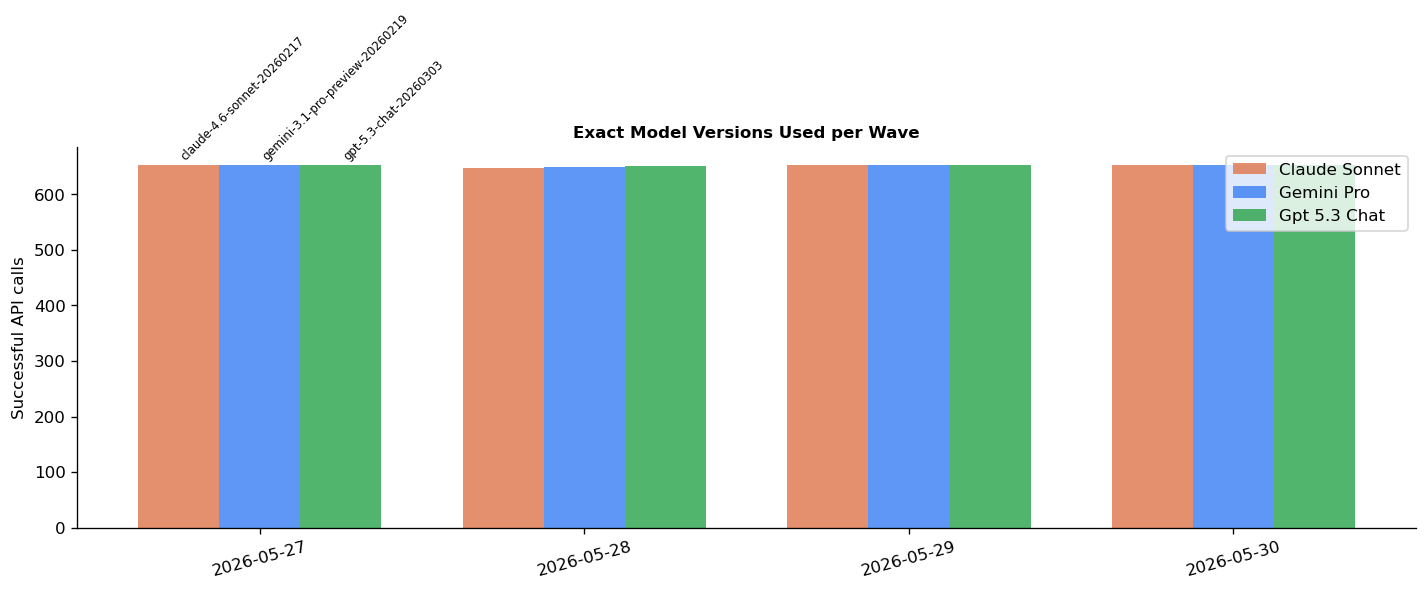

wave,2026-05-27,2026-05-28,2026-05-29,2026-05-30
model_used,,,,
anthropic/claude-4.6-sonnet-20260217,652,648,652,652
google/gemini-3.1-pro-preview-20260219,652,649,652,652
openai/gpt-5.3-chat-20260303,652,651,652,652


In [50]:
# Exact model versions used per wave
version_df = query_db(f"""
    SELECT sw.name AS wave, mc.display_name AS model, rr.model_used,
           COUNT(*) AS n_calls
    FROM response_records rr
    JOIN study_waves sw   ON sw.id = rr.wave_id
    JOIN model_configs mc ON mc.id = rr.model_config_id
    WHERE sw.name IN {WAVE_IN}
      AND mc.display_name IN {MODEL_IN}
      AND rr.error IS NULL
    GROUP BY sw.name, mc.display_name, rr.model_used
    ORDER BY sw.name, mc.display_name
""")

version_df['version_label'] = version_df['model_used'].str.split('/').str[-1]

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(WAVES))
width   = 0.25
offsets = np.linspace(-(len(MAIN_MODELS)-1)/2, (len(MAIN_MODELS)-1)/2, len(MAIN_MODELS)) * width

for i, model in enumerate(MAIN_MODELS):
    sub     = version_df[version_df['model'] == model].sort_values('wave')
    counts  = sub['n_calls'].values
    bars    = ax.bar(x + offsets[i], counts, width, label=model,
                     color=MODEL_COLORS[model], alpha=0.85)
    version = sub['version_label'].iloc[0] if len(sub) else ''
    # Annotate only the first bar with the exact version string
    for j, bar in enumerate(bars):
        if j == 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 5,
                    version, fontsize=7, rotation=45, ha='left', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(WAVES, rotation=15)
ax.set_ylabel('Successful API calls')
ax.set_title('Exact Model Versions Used per Wave', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

version_df.pivot_table(index='model_used', columns='wave', values='n_calls', aggfunc='sum')

---
## 1. WVS: Alignment with Global Distribution

Each model returns a probability distribution over answer options (e.g. `{"A": 0.55, "B": 0.10, ...}`). We compare this to the WVS crowd-sourced `global_distribution` using **Total Variation (TV) distance** — half the L1 norm between the two distributions. TV ∈ [0, 1]; 0 = identical, 1 = maximally different.

In [51]:
def parse_wvs_response(text):
    """JSON text → (probs_array, option_letters) or None."""
    if not text:
        return None
    text = text.strip()
    if text.startswith('```'):
        text = text.split('```')[1].lstrip('json').strip()
    try:
        d = json.loads(text)
        if not isinstance(d, dict):
            return None
        defined = {k: float(v) for k, v in d.items() if k in OPT_LETTERS}
        if not defined:
            return None
        letters = sorted(defined.keys())
        probs   = np.array([defined[k] for k in letters], dtype=float)
        s = probs.sum()
        return (probs / s if s > 0 else probs), letters
    except Exception:
        return None

def tv_distance(p, q):
    n = min(len(p), len(q))
    return 0.5 * float(np.sum(np.abs(p[:n] - q[:n])))

rows = []
for _, r in wvs_df.iterrows():
    parsed = parse_wvs_response(r['response_text'])
    if parsed is None:
        continue
    probs, letters = parsed
    item = wvs_meta.get(r['item_id'])
    if item is None:
        continue
    n_opts = len(item['options'])
    gd = np.array(item['global_distribution'][:n_opts], dtype=float)
    if gd.sum() > 0:
        gd = gd / gd.sum()
    tv = tv_distance(probs, gd)
    ent_model  = float(-np.sum(probs * np.log(probs + 1e-12)))
    ent_global = float(item.get('entropy', np.nan))
    rows.append({'wave': r['wave'], 'model': r['model'], 'item_id': r['item_id'],
                 'tv': tv, 'ent_model': ent_model, 'ent_global': ent_global,
                 'probs': probs})

tv_df = pd.DataFrame(rows)
print(f'Parsed {len(tv_df):,} / {len(wvs_df):,} WVS responses')
tv_df.groupby(['model', 'wave'])['tv'].agg(['mean', 'median', 'std']).round(3)

Parsed 4,125 / 4,222 WVS responses


mean  median    std
model         wave                            
Claude Sonnet 2026-05-27  0.245   0.213  0.150
              2026-05-28  0.248   0.214  0.151
              2026-05-29  0.250   0.212  0.155
              2026-05-30  0.246   0.213  0.151
Gemini Pro    2026-05-27  0.292   0.194  0.267
              2026-05-28  0.299   0.199  0.272
              2026-05-29  0.291   0.200  0.260
              2026-05-30  0.290   0.186  0.273
Gpt 5.3 Chat  2026-05-27  0.390   0.346  0.241
              2026-05-28  0.405   0.356  0.244
              2026-05-29  0.399   0.350  0.242
              2026-05-30  0.406   0.366  0.246

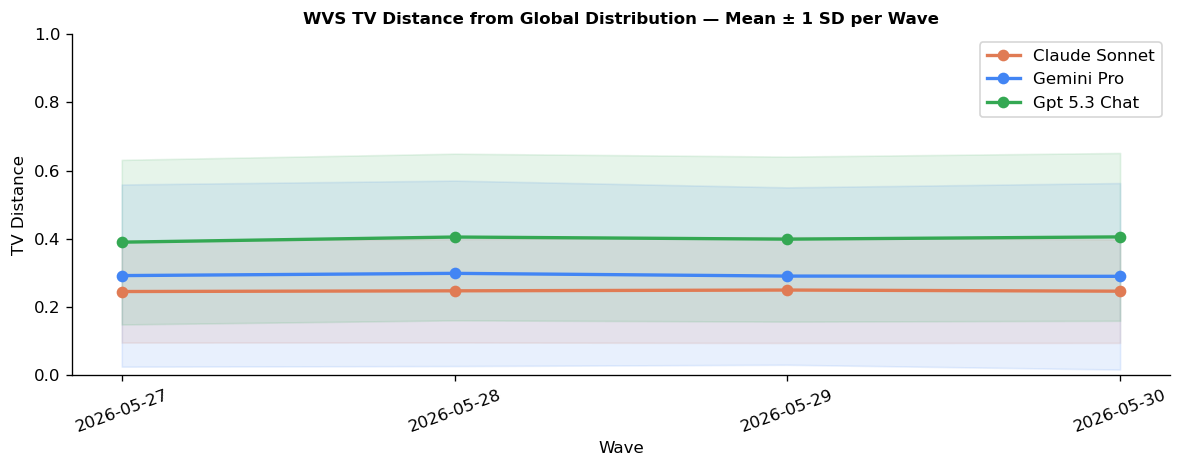

In [52]:
tv_agg = tv_df.groupby(['model', 'wave'])['tv'].agg(['mean', 'std']).reset_index().sort_values('wave')

fig, ax = plt.subplots(figsize=(10, 4))
for model in MAIN_MODELS:
    s = tv_agg[tv_agg['model'] == model]
    ax.plot(s['wave'], s['mean'], marker='o', lw=2, label=model, color=MODEL_COLORS[model])
    ax.fill_between(s['wave'], s['mean'] - s['std'], s['mean'] + s['std'],
                    alpha=0.12, color=MODEL_COLORS[model])
ax.set_ylim(0, 1)
ax.set_title('WVS TV Distance from Global Distribution — Mean ± 1 SD per Wave', fontweight='bold')
ax.set_xlabel('Wave')
ax.set_ylabel('TV Distance')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

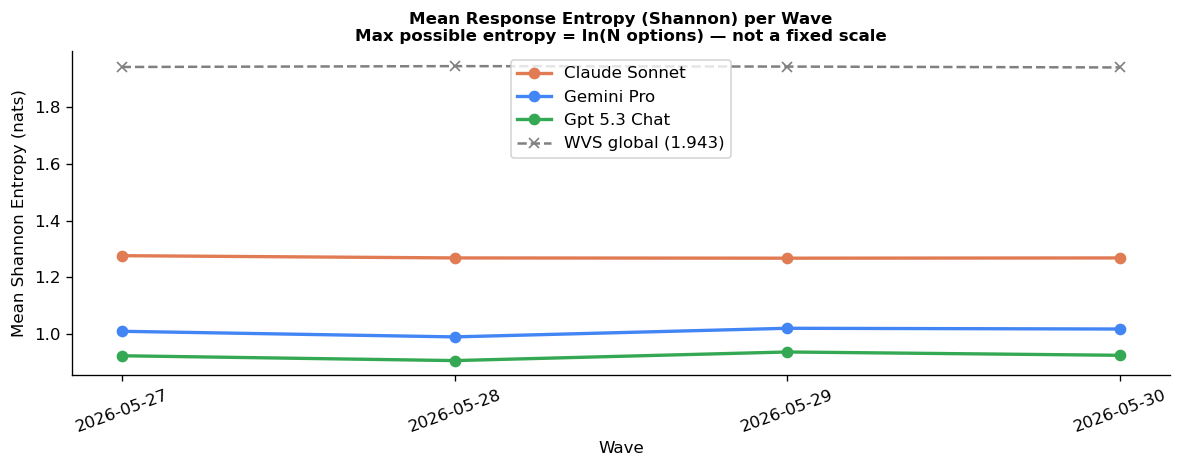

WVS global mean entropy : 1.943  (averaged over 352 items)
Note: max entropy = ln(N) — e.g. ln(4)=1.386, ln(6)=1.792, ln(8)=2.079


In [73]:
ent_agg    = tv_df.groupby(['model', 'wave'])['ent_model'].mean().reset_index().sort_values('wave')
global_ent = tv_df.groupby('wave')['ent_global'].mean().reset_index().sort_values('wave')
global_val = round(global_ent['ent_global'].mean(), 3)

fig, ax = plt.subplots(figsize=(10, 4))
for model in MAIN_MODELS:
    s = ent_agg[ent_agg['model'] == model]
    ax.plot(s['wave'], s['ent_model'], marker='o', lw=2, label=model, color=MODEL_COLORS[model])
ax.plot(global_ent['wave'], global_ent['ent_global'],
        marker='x', lw=1.5, ls='--', color='gray', label=f'WVS global ({global_val})')

ax.set_title('Mean Response Entropy (Shannon) per Wave\n'
             'Max possible entropy = ln(N options) — not a fixed scale', fontweight='bold')
ax.set_xlabel('Wave')
ax.set_ylabel('Mean Shannon Entropy (nats)')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

print(f'WVS global mean entropy : {global_val}  (averaged over {len(tv_df["item_id"].unique())} items)')
print(f'Note: max entropy = ln(N) — e.g. ln(4)={round(__import__("math").log(4),3)},',
      f'ln(6)={round(__import__("math").log(6),3)}, ln(8)={round(__import__("math").log(8),3)}')

---
## 2. Day-over-Day WVS Stability

For each model and each WVS item, compute TV distance between its distributions on **consecutive waves**. Low values = stable responses; high values = the model's answer shifted.

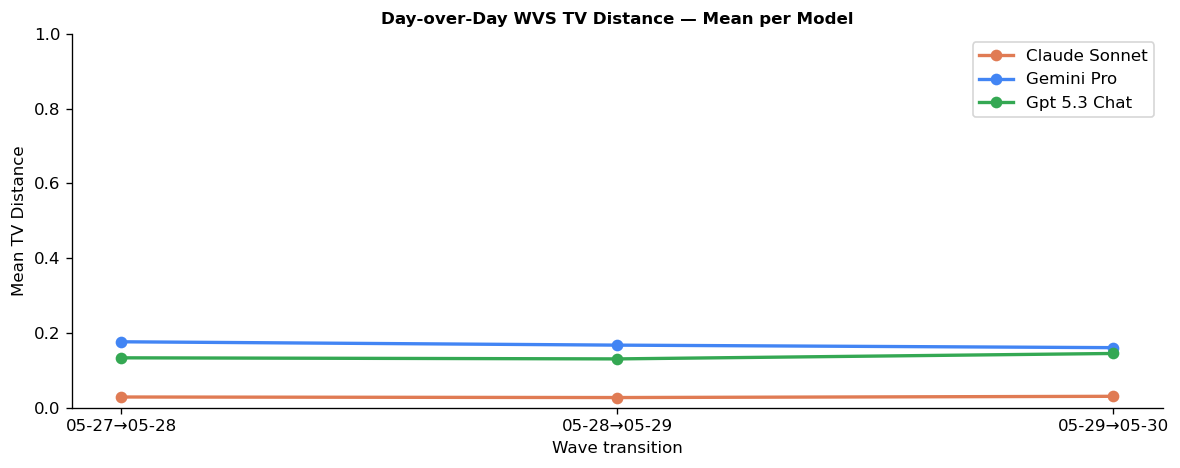

mean    std
model         pair                     
Claude Sonnet 05-27→05-28  0.029  0.056
              05-28→05-29  0.027  0.071
              05-29→05-30  0.030  0.071
Gemini Pro    05-27→05-28  0.176  0.296
              05-28→05-29  0.167  0.279
              05-29→05-30  0.161  0.277
Gpt 5.3 Chat  05-27→05-28  0.133  0.197
              05-28→05-29  0.131  0.185
              05-29→05-30  0.145  0.205

In [54]:
dod_rows = []
for model in MAIN_MODELS:
    mdf = tv_df[tv_df['model'] == model]
    for w1, w2 in CONSEC:
        d1 = mdf[mdf['wave'] == w1].set_index('item_id')['probs']
        d2 = mdf[mdf['wave'] == w2].set_index('item_id')['probs']
        common = d1.index.intersection(d2.index)
        for item in common:
            n  = min(len(d1[item]), len(d2[item]))
            tv = tv_distance(d1[item][:n], d2[item][:n])
            dod_rows.append({'model': model, 'pair': f'{w1[-5:]}→{w2[-5:]}', 'tv': tv})

dod_df   = pd.DataFrame(dod_rows)
dod_mean = dod_df.groupby(['model', 'pair'])['tv'].mean().reset_index()
pairs_l  = [f'{w1[-5:]}→{w2[-5:]}' for w1, w2 in CONSEC]

fig, ax = plt.subplots(figsize=(10, 4))
for model in MAIN_MODELS:
    s = dod_mean[dod_mean['model'] == model].set_index('pair').reindex(pairs_l)
    ax.plot(pairs_l, s['tv'], marker='o', lw=2, label=model, color=MODEL_COLORS[model])
ax.set_ylim(0, 1)
ax.set_title('Day-over-Day WVS TV Distance — Mean per Model', fontweight='bold')
ax.set_xlabel('Wave transition')
ax.set_ylabel('Mean TV Distance')
ax.legend()
plt.tight_layout()
plt.show()

dod_df.groupby(['model', 'pair'])['tv'].agg(['mean', 'std']).round(3)

---
## 3. Model Agreement on WVS

For each item and wave, compute **pairwise cosine similarity** between the three models' probability distributions. High similarity = models give similar distributions.

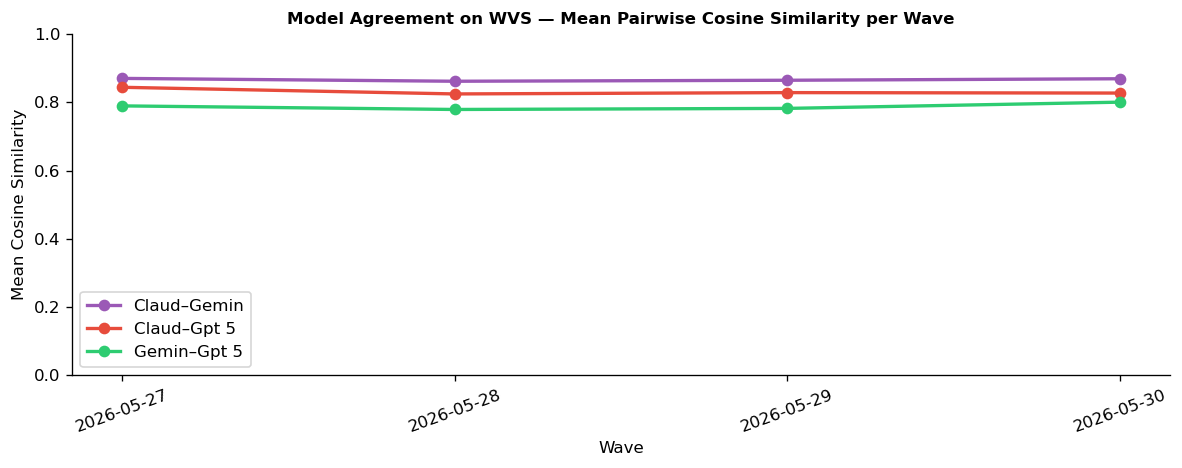

wave,2026-05-27,2026-05-28,2026-05-29,2026-05-30
pair,,,,
Claud–Gemin,0.870,0.862,0.864,0.869
Claud–Gpt 5,0.844,0.824,0.828,0.827
Gemin–Gpt 5,0.789,0.779,0.782,0.800


In [55]:
agree_rows = []
for wave in WAVES:
    wdf = tv_df[tv_df['wave'] == wave]
    for m1, m2 in MODEL_PAIRS:
        d1 = wdf[wdf['model'] == m1].set_index('item_id')['probs']
        d2 = wdf[wdf['model'] == m2].set_index('item_id')['probs']
        common = d1.index.intersection(d2.index)
        for item in common:
            n  = min(len(d1[item]), len(d2[item]))
            p1, p2 = d1[item][:n], d2[item][:n]
            if np.linalg.norm(p1) > 0 and np.linalg.norm(p2) > 0:
                sim = 1.0 - cosine_dist(p1, p2)
                agree_rows.append({'wave': wave, 'pair': f'{m1[:5]}–{m2[:5]}', 'sim': sim})

agree_df    = pd.DataFrame(agree_rows)
PAIR_COLORS = dict(zip([f'{a[:5]}–{b[:5]}' for a, b in MODEL_PAIRS],
                       ['#9b59b6', '#e74c3c', '#2ecc71']))
agree_mean  = agree_df.groupby(['pair', 'wave'])['sim'].mean().reset_index().sort_values('wave')

fig, ax = plt.subplots(figsize=(10, 4))
for pair in agree_df['pair'].unique():
    s = agree_mean[agree_mean['pair'] == pair]
    ax.plot(s['wave'], s['sim'], marker='o', lw=2, label=pair,
            color=PAIR_COLORS.get(pair, 'gray'))
ax.set_ylim(0, 1)
ax.set_title('Model Agreement on WVS — Mean Pairwise Cosine Similarity per Wave', fontweight='bold')
ax.set_xlabel('Wave')
ax.set_ylabel('Mean Cosine Similarity')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

agree_mean.pivot_table(index='pair', columns='wave', values='sim').round(3)

---
## 4. Cosine Similarity of Persona Responses

Using `sentence-transformers/all-MiniLM-L6-v2` to embed each response, then computing cosine similarity across three axes:

- **4a Day-over-day** — same model, same prompt (baseline), wave N vs wave N+1  
- **4b Condition gap** — same model, same query: baseline vs high_ses · baseline vs low_ses  
- **4c Between-model** — same prompt, same wave, across model pairs

> Embedding ~3 600 responses takes a few minutes on CPU.

In [56]:
from sentence_transformers import SentenceTransformer

print('Loading embedding model…')
embedder = SentenceTransformer('all-MiniLM-L6-v2')

texts = persona_df['response_text'].fillna('').tolist()
print(f'Embedding {len(texts):,} responses…')
embedding_matrix = embedder.encode(texts, batch_size=64, show_progress_bar=True,
                                   convert_to_numpy=True)
persona_df = persona_df.copy()
persona_df['emb_idx'] = range(len(texts))
print(f'Done. Matrix shape: {embedding_matrix.shape}')

Loading embedding model…
Embedding 3,594 responses…


Batches: 100%|██████████| 57/57 [05:21<00:00,  5.65s/it]


Done. Matrix shape: (3594, 384)


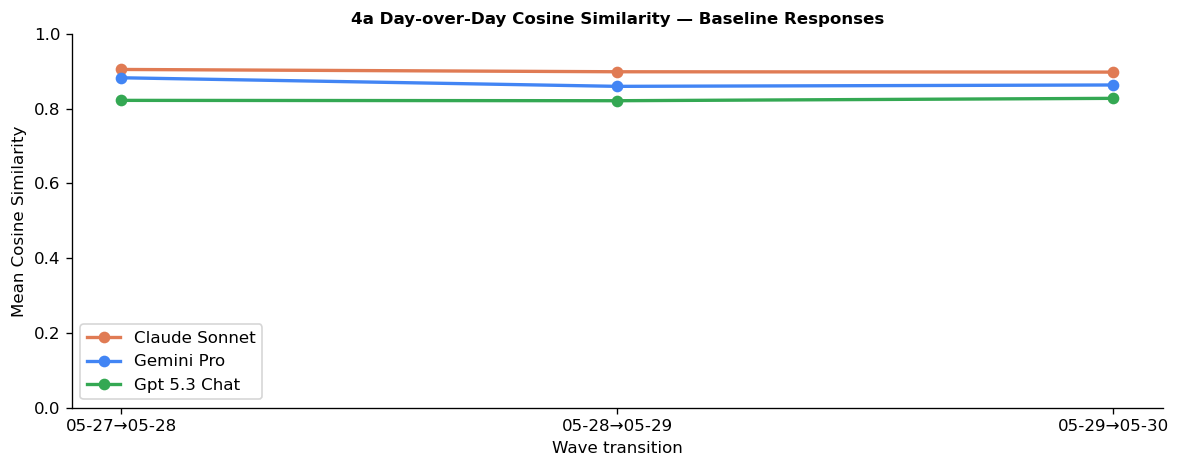

mean    std
model         pair                     
Claude Sonnet 05-27→05-28  0.905  0.070
              05-28→05-29  0.899  0.073
              05-29→05-30  0.898  0.075
Gemini Pro    05-27→05-28  0.883  0.166
              05-28→05-29  0.860  0.176
              05-29→05-30  0.864  0.164
Gpt 5.3 Chat  05-27→05-28  0.822  0.106
              05-28→05-29  0.821  0.108
              05-29→05-30  0.828  0.094

In [57]:
baseline_df = persona_df[persona_df['condition'] == 'baseline'].copy()

dod_text_rows = []
for model in MAIN_MODELS:
    mdf = baseline_df[baseline_df['model'] == model]
    for w1, w2 in CONSEC:
        d1 = mdf[mdf['wave'] == w1].set_index('item_id')['emb_idx']
        d2 = mdf[mdf['wave'] == w2].set_index('item_id')['emb_idx']
        for item in d1.index.intersection(d2.index):
            sim = 1.0 - cosine_dist(embedding_matrix[d1[item]], embedding_matrix[d2[item]])
            dod_text_rows.append({'model': model, 'pair': f'{w1[-5:]}→{w2[-5:]}', 'sim': sim})

dod_text_df   = pd.DataFrame(dod_text_rows)
dod_text_mean = dod_text_df.groupby(['model', 'pair'])['sim'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
for model in MAIN_MODELS:
    s = dod_text_mean[dod_text_mean['model'] == model].set_index('pair').reindex(pairs_l)
    ax.plot(pairs_l, s['sim'], marker='o', lw=2, label=model, color=MODEL_COLORS[model])
ax.set_ylim(0, 1)
ax.set_title('4a Day-over-Day Cosine Similarity — Baseline Responses', fontweight='bold')
ax.set_xlabel('Wave transition')
ax.set_ylabel('Mean Cosine Similarity')
ax.legend()
plt.tight_layout()
plt.show()

dod_text_df.groupby(['model', 'pair'])['sim'].agg(['mean', 'std']).round(3)

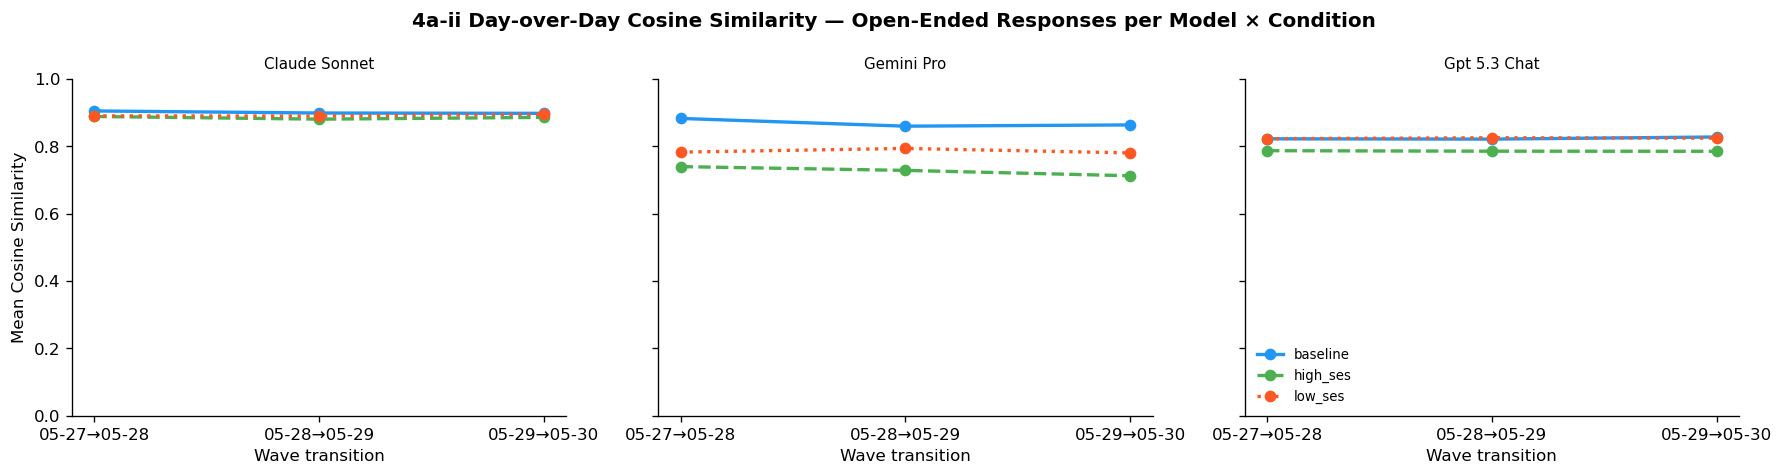

mean    std
model         condition              
Claude Sonnet baseline   0.901  0.072
              high_ses   0.885  0.076
              low_ses    0.892  0.074
Gemini Pro    baseline   0.869  0.168
              high_ses   0.727  0.262
              low_ses    0.786  0.230
Gpt 5.3 Chat  baseline   0.824  0.103
              high_ses   0.786  0.098
              low_ses    0.824  0.079

In [58]:
dod_all_rows = []
for model in MAIN_MODELS:
    mdf = persona_df[persona_df['model'] == model]
    for cond in CONDITIONS:
        cdf = mdf[mdf['condition'] == cond].drop_duplicates(['wave', 'item_id'])
        for w1, w2 in CONSEC:
            d1 = cdf[cdf['wave'] == w1].set_index('item_id')['emb_idx']
            d2 = cdf[cdf['wave'] == w2].set_index('item_id')['emb_idx']
            for item in d1.index.intersection(d2.index):
                sim = 1.0 - cosine_dist(embedding_matrix[d1[item]], embedding_matrix[d2[item]])
                dod_all_rows.append({'model': model, 'condition': cond,
                                     'pair': f'{w1[-5:]}→{w2[-5:]}', 'sim': sim})

dod_all_df   = pd.DataFrame(dod_all_rows)
dod_all_mean = dod_all_df.groupby(['model', 'condition', 'pair'])['sim'].mean().reset_index()

fig, axes = plt.subplots(1, len(MAIN_MODELS), figsize=(15, 4), sharey=True)
fig.suptitle('4a-ii Day-over-Day Cosine Similarity — Open-Ended Responses per Model × Condition',
             fontweight='bold')
for ax, model in zip(axes, MAIN_MODELS):
    mdf = dod_all_mean[dod_all_mean['model'] == model]
    for cond in CONDITIONS:
        s = mdf[mdf['condition'] == cond].set_index('pair').reindex(pairs_l)
        ax.plot(pairs_l, s['sim'], marker='o', lw=2, label=cond,
                color=COND_COLORS[cond], linestyle=COND_LS[cond])
    ax.set_ylim(0, 1)
    ax.set_title(model, fontsize=9)
    ax.set_xlabel('Wave transition')
    if ax is axes[0]:
        ax.set_ylabel('Mean Cosine Similarity')
axes[-1].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

dod_all_df.groupby(['model', 'condition'])['sim'].agg(['mean', 'std']).round(3)

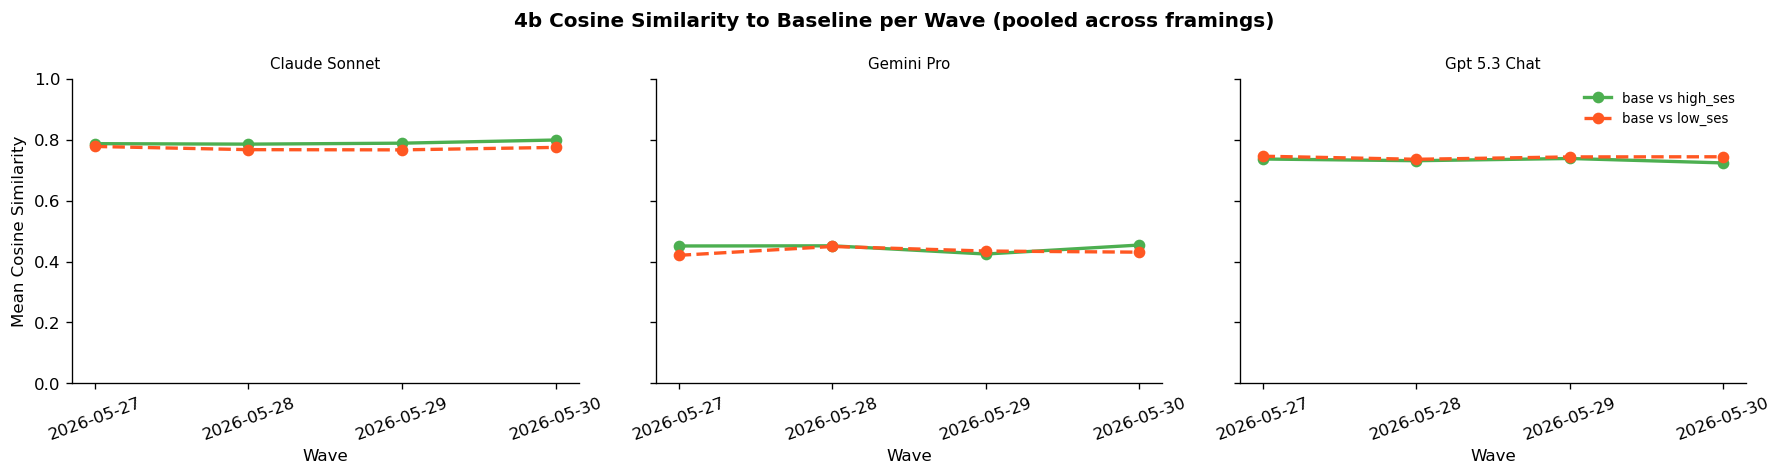

wave                            2026-05-27  2026-05-28  2026-05-29  2026-05-30
model         comparison                                                      
Claude Sonnet base vs high_ses       0.788       0.786       0.789       0.799
              base vs low_ses        0.778       0.768       0.767       0.775
Gemini Pro    base vs high_ses       0.451       0.452       0.425       0.454
              base vs low_ses        0.421       0.450       0.435       0.431
Gpt 5.3 Chat  base vs high_ses       0.737       0.731       0.739       0.724
              base vs low_ses        0.746       0.736       0.744       0.744

In [74]:
# 4b: Cosine similarity to baseline — pooled across framings and sources
# Fix: loop over (source × framing) so query_id is unique within each group,
# then aggregate across both to get the overall SES effect.
cond_sim_rows = []
for model in MAIN_MODELS:
    for wave in WAVES:
        mw = persona_df[(persona_df['model'] == model) & (persona_df['wave'] == wave)]
        for source in ['advertising', 'infinity_chat']:
            src  = mw[mw['query_source'] == source]
            base = src[src['condition'] == 'baseline'].set_index('query_id')['emb_idx']
            if base.empty:
                continue
            for framing in ['system_msg', 'inline_prompt']:
                fdf = src[src['framing'] == framing]
                for ses_cond in [c for c in fdf['condition'].unique() if c != 'baseline']:
                    ses_label = 'base vs high_ses' if 'high' in ses_cond else 'base vs low_ses'
                    ses_rows  = fdf[fdf['condition'] == ses_cond].set_index('query_id')['emb_idx']
                    for qid in base.index.intersection(ses_rows.index):
                        sim = 1.0 - cosine_dist(embedding_matrix[base[qid]], embedding_matrix[ses_rows[qid]])
                        cond_sim_rows.append({'model': model, 'wave': wave,
                                              'comparison': ses_label, 'sim': sim})

cond_sim_df   = pd.DataFrame(cond_sim_rows)
cond_sim_mean = cond_sim_df.groupby(['model', 'comparison', 'wave'])['sim'].mean().reset_index().sort_values('wave')
CMP_COLORS = {'base vs high_ses': '#4CAF50', 'base vs low_ses': '#FF5722'}
CMP_LS     = {'base vs high_ses': '-', 'base vs low_ses': '--'}

fig, axes = plt.subplots(1, len(MAIN_MODELS), figsize=(15, 4), sharey=True)
fig.suptitle('4b Cosine Similarity to Baseline per Wave (pooled across framings)', fontweight='bold')
for ax, model in zip(axes, MAIN_MODELS):
    mdf = cond_sim_mean[cond_sim_mean['model'] == model]
    for cmp in ['base vs high_ses', 'base vs low_ses']:
        s = mdf[mdf['comparison'] == cmp]
        ax.plot(s['wave'], s['sim'], marker='o', lw=2, label=cmp,
                color=CMP_COLORS[cmp], linestyle=CMP_LS[cmp])
    ax.set_ylim(0, 1)
    ax.set_title(model, fontsize=9)
    ax.set_xlabel('Wave')
    ax.tick_params(axis='x', rotation=20)
    if ax is axes[0]:
        ax.set_ylabel('Mean Cosine Similarity')
axes[-1].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

cond_sim_mean.pivot_table(index=['model', 'comparison'], columns='wave', values='sim').round(3)

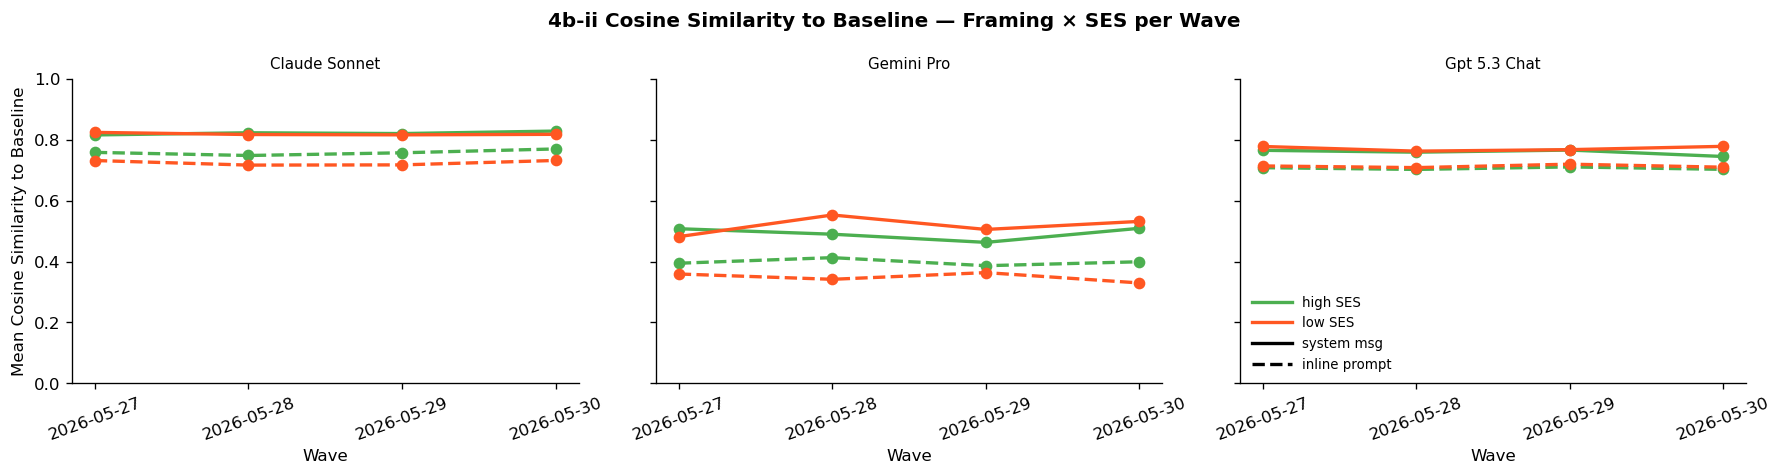

wave                                  2026-05-27  2026-05-28  2026-05-29  \
model         framing       ses                                            
Claude Sonnet inline_prompt high_ses       0.759       0.749       0.758   
                            low_ses        0.732       0.717       0.718   
              system_msg    high_ses       0.816       0.823       0.821   
                            low_ses        0.825       0.818       0.817   
Gemini Pro    inline_prompt high_ses       0.395       0.413       0.386   
                            low_ses        0.359       0.342       0.364   
              system_msg    high_ses       0.508       0.490       0.463   
                            low_ses        0.482       0.553       0.506   
Gpt 5.3 Chat  inline_prompt high_ses       0.709       0.703       0.711   
                            low_ses        0.714       0.709       0.720   
              system_msg    high_ses       0.766       0.760       0.766   
                            low_ses        0.778       0.763       0.768   

wave                                  2026-05-30  
model         framing       ses                   
Claude Sonnet inline_prompt high_ses       0.770  
                            low_ses        0.732  
              system_msg    high_ses       0.829  
                            low_ses        0.818  
Gemini Pro    inline_prompt high_ses       0.399  
                            low_ses        0.330  
              system_msg    high_ses       0.509  
                            low_ses        0.532  
Gpt 5.3 Chat  inline_prompt high_ses       0.703  
                            low_ses        0.710  
              system_msg    high_ses       0.745  
                            low_ses        0.779

In [70]:
from matplotlib.lines import Line2D

framing_cond_rows = []
for model in MAIN_MODELS:
    for wave in WAVES:
        mw = persona_df[(persona_df['model'] == model) & (persona_df['wave'] == wave)]
        for source in ['advertising', 'infinity_chat']:
            src  = mw[mw['query_source'] == source]
            base = src[src['condition'] == 'baseline'].set_index('query_id')['emb_idx']
            if base.empty:
                continue
            for framing in ['system_msg', 'inline_prompt']:
                fdf = src[src['framing'] == framing]
                for ses_cond in [c for c in fdf['condition'].unique() if c != 'baseline']:
                    ses_rows  = fdf[fdf['condition'] == ses_cond].set_index('query_id')['emb_idx']
                    ses_label = 'high_ses' if 'high' in ses_cond else 'low_ses'
                    for qid in base.index.intersection(ses_rows.index):
                        sim = 1.0 - cosine_dist(
                            embedding_matrix[base[qid]], embedding_matrix[ses_rows[qid]]
                        )
                        framing_cond_rows.append({
                            'model': model, 'wave': wave,
                            'framing': framing, 'ses': ses_label, 'sim': sim
                        })

framing_cond_df   = pd.DataFrame(framing_cond_rows)
framing_cond_mean = (framing_cond_df
    .groupby(['model', 'framing', 'ses', 'wave'])['sim']
    .mean().reset_index().sort_values('wave'))

SES_COLORS = {'high_ses': '#4CAF50', 'low_ses': '#FF5722'}
FRAMING_LS = {'system_msg': '-', 'inline_prompt': '--'}

fig, axes = plt.subplots(1, len(MAIN_MODELS), figsize=(15, 4), sharey=True)
fig.suptitle('4b-ii Cosine Similarity to Baseline — Framing × SES per Wave', fontweight='bold')
for ax, model in zip(axes, MAIN_MODELS):
    mdf = framing_cond_mean[framing_cond_mean['model'] == model]
    for (framing, ses), grp in mdf.groupby(['framing', 'ses']):
        ax.plot(grp['wave'], grp['sim'], marker='o', lw=2,
                color=SES_COLORS[ses], linestyle=FRAMING_LS[framing])
    ax.set_ylim(0, 1)
    ax.set_title(model, fontsize=9)
    ax.set_xlabel('Wave')
    ax.tick_params(axis='x', rotation=20)
    if ax is axes[0]:
        ax.set_ylabel('Mean Cosine Similarity to Baseline')

# Split legend: top section = SES color, bottom section = framing linestyle
legend_handles = [
    Line2D([0], [0], color='#4CAF50', lw=2, linestyle='-',  label='high SES'),
    Line2D([0], [0], color='#FF5722', lw=2, linestyle='-',  label='low SES'),
    Line2D([0], [0], color='black',   lw=2, linestyle='-',  label='system msg'),
    Line2D([0], [0], color='black',   lw=2, linestyle='--', label='inline prompt'),
]
axes[-1].legend(handles=legend_handles, fontsize=8, frameon=False,
                handlelength=3)
plt.tight_layout()
plt.show()

framing_cond_mean.pivot_table(index=['model', 'framing', 'ses'],
                               columns='wave', values='sim').round(3)

In [ ]:
# 4c: Between-model cosine similarity per condition per wave
# Fix: loop over (source × framing) so query_id is unique, then pool across both.
inter_rows = []
for wave in WAVES:
    wdf = persona_df[persona_df['wave'] == wave]
    for source in ['advertising', 'infinity_chat']:
        src = wdf[wdf['query_source'] == source]
        for framing in ['system_msg', 'inline_prompt']:
            fdf = src[src['framing'] == framing]
            for cond in CONDITIONS:
                for m1, m2 in MODEL_PAIRS:
                    d1 = fdf[(fdf['model'] == m1) & (fdf['condition'] == cond)].set_index('query_id')['emb_idx']
                    d2 = fdf[(fdf['model'] == m2) & (fdf['condition'] == cond)].set_index('query_id')['emb_idx']
                    for qid in d1.index.intersection(d2.index):
                        sim = 1.0 - cosine_dist(embedding_matrix[d1[qid]], embedding_matrix[d2[qid]])
                        inter_rows.append({'wave': wave, 'condition': cond,
                                           'pair': f'{m1[:5]}–{m2[:5]}', 'sim': sim})

inter_df   = pd.DataFrame(inter_rows)
inter_mean = inter_df.groupby(['condition', 'pair', 'wave'])['sim'].mean().reset_index().sort_values('wave')

fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(15, 4), sharey=True)
fig.suptitle('4c Between-Model Cosine Similarity per Condition per Wave', fontweight='bold')
for ax, cond in zip(axes, CONDITIONS):
    mdf = inter_mean[inter_mean['condition'] == cond]
    for pair in inter_df['pair'].unique():
        s = mdf[mdf['pair'] == pair]
        ax.plot(s['wave'], s['sim'], marker='o', lw=2, label=pair,
                color=PAIR_COLORS.get(pair, 'gray'))
    ax.set_ylim(0, 1)
    ax.set_title(cond, fontsize=9)
    ax.set_xlabel('Wave')
    ax.tick_params(axis='x', rotation=20)
    if ax is axes[0]:
        ax.set_ylabel('Mean Cosine Similarity')
axes[-1].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

inter_mean.pivot_table(index=['condition', 'pair'], columns='wave', values='sim').round(3)

---
## 5. Response Length per Model × Condition

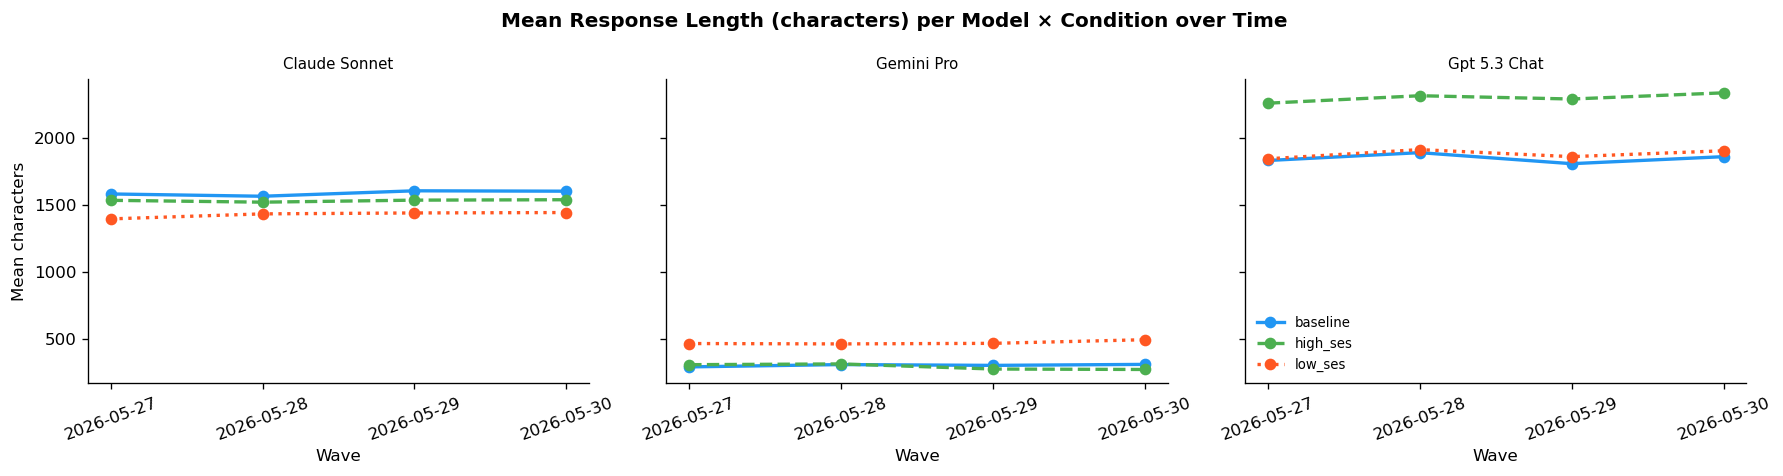

wave                     2026-05-27  2026-05-28  2026-05-29  2026-05-30
model         condition                                                
Claude Sonnet baseline       1581.0      1564.0      1605.0      1602.0
              high_ses       1534.0      1520.0      1535.0      1538.0
              low_ses        1395.0      1433.0      1440.0      1443.0
Gemini Pro    baseline        292.0       310.0       304.0       311.0
              high_ses        309.0       314.0       276.0       273.0
              low_ses         466.0       464.0       468.0       495.0
Gpt 5.3 Chat  baseline       1831.0      1889.0      1807.0      1859.0
              high_ses       2258.0      2313.0      2289.0      2335.0
              low_ses        1843.0      1912.0      1859.0      1903.0

In [61]:
len_mean = (persona_df
    .groupby(['model', 'condition', 'wave'])['response_len']
    .mean().reset_index().sort_values('wave'))

fig, axes = plt.subplots(1, len(MAIN_MODELS), figsize=(15, 4), sharey=True)
fig.suptitle('Mean Response Length (characters) per Model × Condition over Time', fontweight='bold')
for ax, model in zip(axes, MAIN_MODELS):
    mdf = len_mean[len_mean['model'] == model]
    for cond in CONDITIONS:
        s = mdf[mdf['condition'] == cond]
        ax.plot(s['wave'], s['response_len'], marker='o', lw=2, label=cond,
                color=COND_COLORS[cond], linestyle=COND_LS[cond])
    ax.set_title(model, fontsize=9)
    ax.set_xlabel('Wave')
    ax.tick_params(axis='x', rotation=20)
    if ax is axes[0]:
        ax.set_ylabel('Mean characters')
axes[-1].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

len_mean.pivot_table(index=['model', 'condition'], columns='wave', values='response_len').round(0)

---
## 6. Sentiment per Model × Condition

Using **TextBlob** polarity score: −1 (negative) → 0 (neutral) → +1 (positive).

Computing sentiment…
Done.


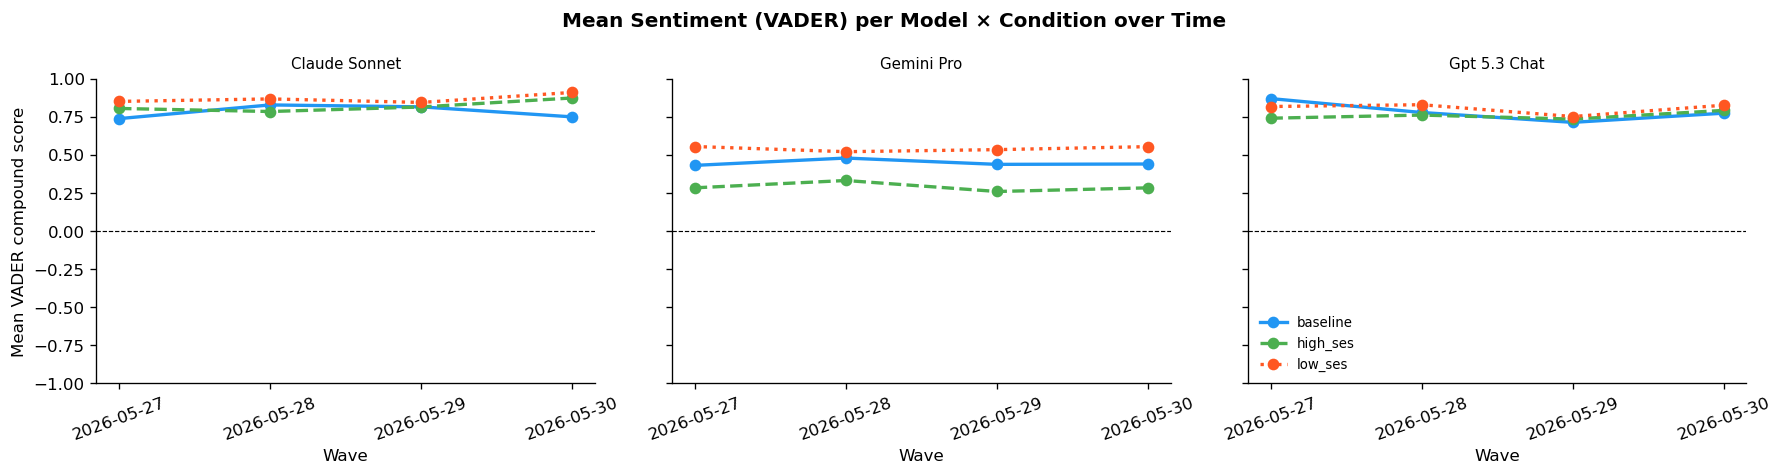

wave                     2026-05-27  2026-05-28  2026-05-29  2026-05-30
model         condition                                                
Claude Sonnet baseline        0.740       0.830       0.817       0.751
              high_ses        0.806       0.786       0.816       0.875
              low_ses         0.853       0.869       0.846       0.912
Gemini Pro    baseline        0.432       0.480       0.439       0.441
              high_ses        0.285       0.333       0.261       0.285
              low_ses         0.556       0.522       0.536       0.555
Gpt 5.3 Chat  baseline        0.871       0.780       0.715       0.775
              high_ses        0.742       0.763       0.737       0.794
              low_ses         0.819       0.831       0.753       0.828

In [62]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

print('Computing sentiment…')
persona_df['sentiment'] = (persona_df['response_text']
    .fillna('')
    .apply(lambda t: analyzer.polarity_scores(t)['compound']))
print('Done.')

sent_mean = (persona_df
    .groupby(['model', 'condition', 'wave'])['sentiment']
    .mean().reset_index().sort_values('wave'))

fig, axes = plt.subplots(1, len(MAIN_MODELS), figsize=(15, 4), sharey=True)
fig.suptitle('Mean Sentiment (VADER) per Model × Condition over Time', fontweight='bold')
for ax, model in zip(axes, MAIN_MODELS):
    mdf = sent_mean[sent_mean['model'] == model]
    for cond in CONDITIONS:
        s = mdf[mdf['condition'] == cond]
        ax.plot(s['wave'], s['sentiment'], marker='o', lw=2,
                label=cond, color=COND_COLORS[cond], linestyle=COND_LS[cond])
    ax.axhline(0, color='black', lw=0.7, ls='--')
    ax.set_ylim(-1, 1)
    ax.set_title(model, fontsize=9)
    ax.set_xlabel('Wave')
    ax.tick_params(axis='x', rotation=20)
    if ax is axes[0]:
        ax.set_ylabel('Mean VADER compound score')
axes[-1].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

sent_mean.pivot_table(index=['model', 'condition'], columns='wave', values='sentiment').round(3)

---
## 7. Data Quality

Error rates per model × wave. May 31 had a near-total API failure — excluded from analyses above.

---
## 8. Persona Framing Format: System Message vs Inline Prompt

The dataset uses two structurally different ways to inject the persona:

| Format | `query_source` | How it's delivered |
|---|---|---|
| **System message** | `advertising` | Persona in the system turn: *"You know that the customer is a neurosurgeon…"* |
| **Inline prompt** | `infinity_chat` | Persona prepended to the user turn: *"I am a neurosurgeon…\n\n[query]"* |

Both formats include high_ses and low_ses variants. This section tests whether the delivery channel changes response length, sentiment, and semantic divergence from baseline.

In [63]:
all_waves = "('2026-05-26','2026-05-26_t0','2026-05-27','2026-05-28','2026-05-29','2026-05-30','2026-05-31')"
err_df = query_db(f"""
    SELECT sw.name AS wave, mc.display_name AS model, di.dataset_name,
           COUNT(*) AS total,
           SUM(CASE WHEN rr.error IS NOT NULL THEN 1 ELSE 0 END) AS errors
    FROM response_records rr
    JOIN study_waves sw   ON sw.id = rr.wave_id
    JOIN model_configs mc ON mc.id = rr.model_config_id
    JOIN dataset_items di ON di.id = rr.item_id
    WHERE sw.name IN {all_waves}
      AND mc.display_name IN {MODEL_IN}
      AND di.dataset_name IN ('global_opinion_qa', 'persona_prompts')
    GROUP BY sw.name, mc.display_name, di.dataset_name
    ORDER BY sw.name, mc.display_name
""")
err_df['error_pct'] = (err_df['errors'] / err_df['total'] * 100).round(1)
err_df

,wave,model,dataset_name,total,errors,error_pct
0,2026-05-27,Claude Sonnet,global_opinion_qa,352,0,0.0
1,2026-05-27,Claude Sonnet,persona_prompts,300,0,0.0
2,2026-05-27,Gemini Pro,global_opinion_qa,352,0,0.0
3,2026-05-27,Gemini Pro,persona_prompts,300,0,0.0
4,2026-05-27,Gpt 5.3 Chat,global_opinion_qa,352,0,0.0
5,2026-05-27,Gpt 5.3 Chat,persona_prompts,300,0,0.0
6,2026-05-28,Claude Sonnet,global_opinion_qa,351,0,0.0
7,2026-05-28,Claude Sonnet,persona_prompts,297,0,0.0
8,2026-05-28,Gemini Pro,global_opinion_qa,351,0,0.0
9,2026-05-28,Gemini Pro,persona_prompts,298,0,0.0


Rows per framing × ses × query_source:
query_source        advertising  infinity_chat
framing       ses                             
inline_prompt high          300            300
              low           298            300
system_msg    high          300            300
              low           300            300


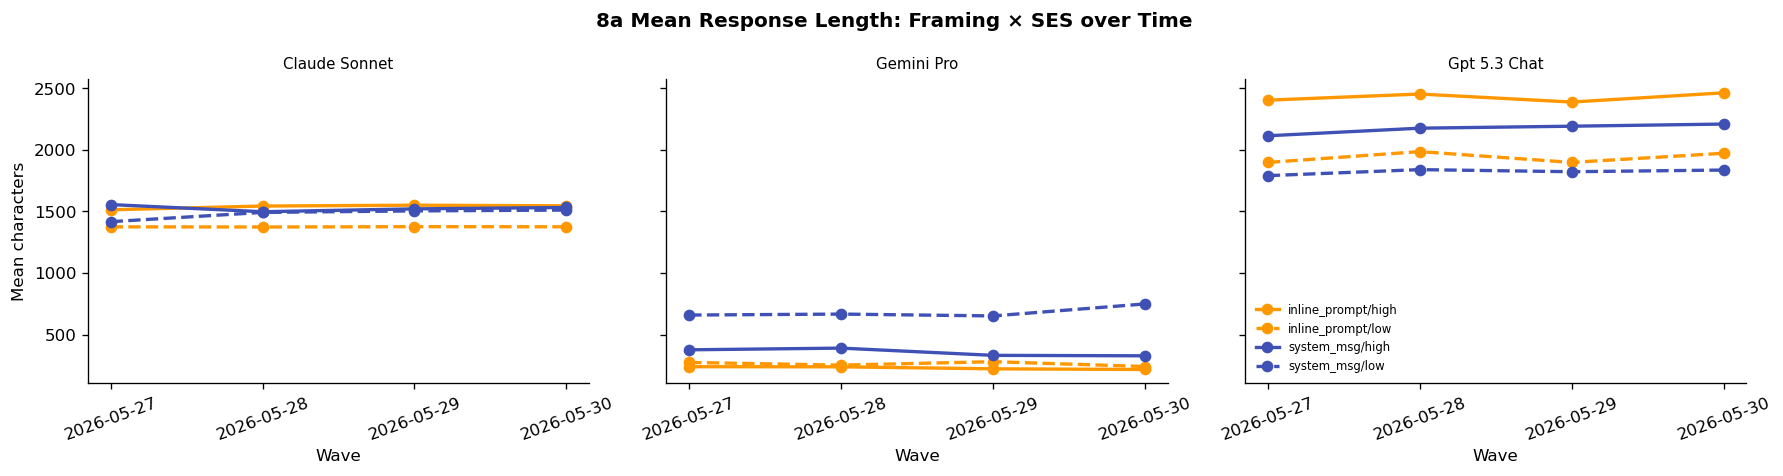

In [64]:
FRAME_COLORS = {'system_msg': '#3F51B5', 'inline_prompt': '#FF9800'}
ses_df = persona_df[persona_df['condition'] != 'baseline'].copy()
ses_df['ses'] = ses_df['condition'].apply(lambda c: 'high' if 'high' in c else 'low')

print('Rows per framing × ses × query_source:')
print(ses_df.groupby(['framing', 'ses', 'query_source'])['wave'].count().unstack(fill_value=0))

# 8a: Mean response length per framing × ses × model over waves
len_frm = (ses_df.groupby(['model', 'framing', 'ses', 'wave'])['response_len']
           .mean().reset_index().sort_values('wave'))

fig, axes = plt.subplots(1, len(MAIN_MODELS), figsize=(15, 4), sharey=True)
fig.suptitle('8a Mean Response Length: Framing × SES over Time', fontweight='bold')
for ax, model in zip(axes, MAIN_MODELS):
    mdf = len_frm[len_frm['model'] == model]
    for (framing, ses), grp in mdf.groupby(['framing', 'ses']):
        ax.plot(grp['wave'], grp['response_len'], marker='o', lw=2,
                color=FRAME_COLORS[framing], linestyle=('-' if ses == 'high' else '--'),
                label=f'{framing}/{ses}')
    ax.set_title(model, fontsize=9)
    ax.set_xlabel('Wave')
    ax.tick_params(axis='x', rotation=20)
    if ax is axes[0]:
        ax.set_ylabel('Mean characters')
axes[-1].legend(fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

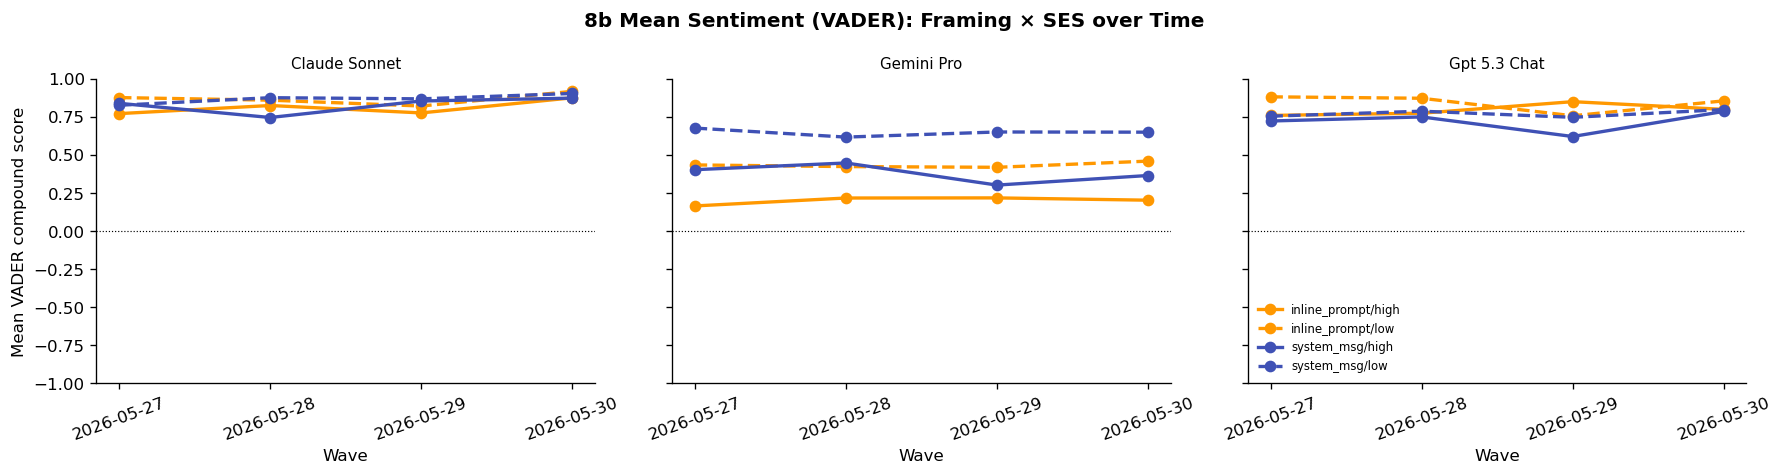

In [65]:
# 8b: Mean sentiment per framing × ses × model over waves
sent_frm = (ses_df.groupby(['model', 'framing', 'ses', 'wave'])['sentiment']
            .mean().reset_index().sort_values('wave'))

fig, axes = plt.subplots(1, len(MAIN_MODELS), figsize=(15, 4), sharey=True)
fig.suptitle('8b Mean Sentiment (VADER): Framing × SES over Time', fontweight='bold')
for ax, model in zip(axes, MAIN_MODELS):
    mdf = sent_frm[sent_frm['model'] == model]
    for (framing, ses), grp in mdf.groupby(['framing', 'ses']):
        ax.plot(grp['wave'], grp['sentiment'], marker='o', lw=2,
                color=FRAME_COLORS[framing], linestyle=('-' if ses == 'high' else '--'),
                label=f'{framing}/{ses}')
    ax.axhline(0, color='black', lw=0.7, ls=':')
    ax.set_ylim(-1, 1)
    ax.set_title(model, fontsize=9)
    ax.set_xlabel('Wave')
    ax.tick_params(axis='x', rotation=20)
    if ax is axes[0]:
        ax.set_ylabel('Mean VADER compound score')
axes[-1].legend(fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

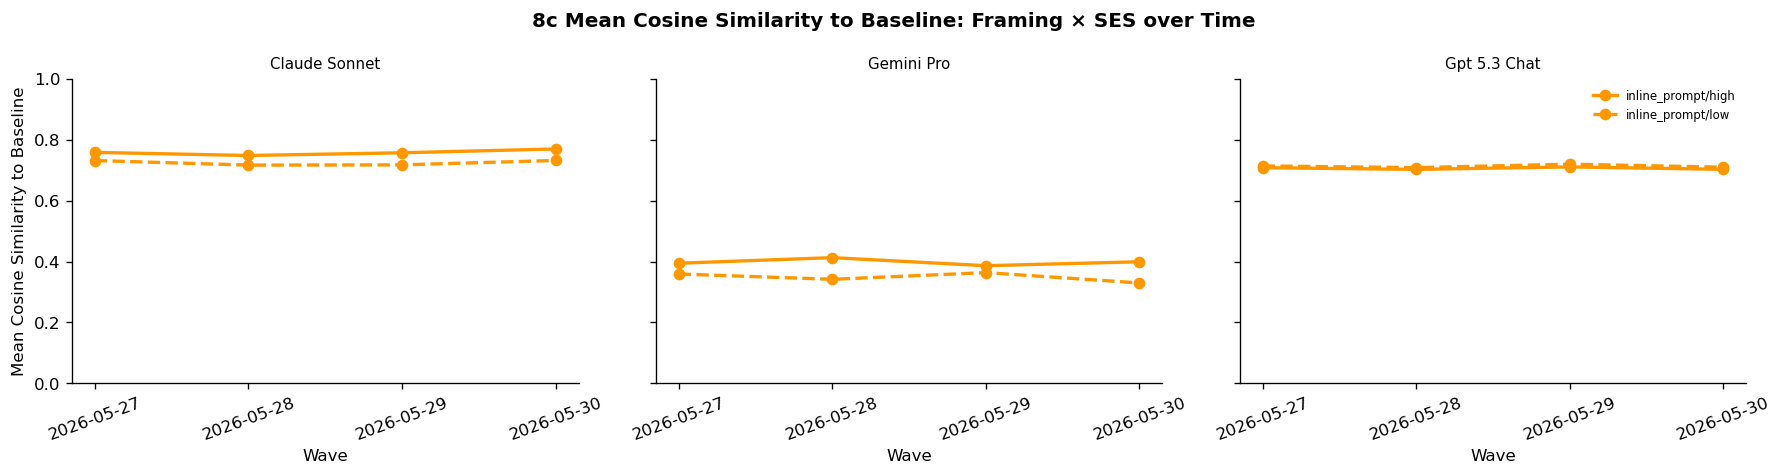

wave                              2026-05-27  2026-05-28  2026-05-29  \
model         framing       ses                                        
Claude Sonnet inline_prompt high       0.759       0.749       0.758   
                            low        0.732       0.717       0.718   
Gemini Pro    inline_prompt high       0.395       0.413       0.386   
                            low        0.359       0.342       0.364   
Gpt 5.3 Chat  inline_prompt high       0.709       0.703       0.711   
                            low        0.714       0.709       0.720   

wave                              2026-05-30  
model         framing       ses               
Claude Sonnet inline_prompt high       0.770  
                            low        0.732  
Gemini Pro    inline_prompt high       0.399  
                            low        0.330  
Gpt 5.3 Chat  inline_prompt high       0.703  
                            low        0.710

In [66]:
framing_sim_rows = []
for model in MAIN_MODELS:
    for wave in WAVES:
        mw = persona_df[(persona_df['model'] == model) & (persona_df['wave'] == wave)]
        for framing in ['system_msg', 'inline_prompt']:
            for source in ['advertising', 'infinity_chat']:
                fdf  = mw[(mw['framing'] == framing) & (mw['query_source'] == source)]
                base = fdf[fdf['condition'] == 'baseline'].set_index('query_id')['emb_idx']
                if base.empty:
                    continue
                for ses_cond in [c for c in fdf['condition'].unique() if c != 'baseline']:
                    ses_rows  = fdf[fdf['condition'] == ses_cond].set_index('query_id')['emb_idx']
                    ses_label = 'high' if 'high' in ses_cond else 'low'
                    for qid in base.index.intersection(ses_rows.index):
                        sim = 1.0 - cosine_dist(
                            embedding_matrix[base[qid]], embedding_matrix[ses_rows[qid]]
                        )
                        framing_sim_rows.append({
                            'model': model, 'wave': wave,
                            'framing': framing, 'ses': ses_label, 'sim': sim
                        })

framing_sim_df   = pd.DataFrame(framing_sim_rows)
framing_sim_mean = (framing_sim_df.groupby(['model', 'framing', 'ses', 'wave'])['sim']
                    .mean().reset_index().sort_values('wave'))

fig, axes = plt.subplots(1, len(MAIN_MODELS), figsize=(15, 4), sharey=True)
fig.suptitle('8c Mean Cosine Similarity to Baseline: Framing × SES over Time', fontweight='bold')
for ax, model in zip(axes, MAIN_MODELS):
    mdf = framing_sim_mean[framing_sim_mean['model'] == model]
    for (framing, ses), grp in mdf.groupby(['framing', 'ses']):
        ax.plot(grp['wave'], grp['sim'], marker='o', lw=2,
                color=FRAME_COLORS[framing], linestyle=('-' if ses == 'high' else '--'),
                label=f'{framing}/{ses}')
    ax.set_ylim(0, 1)
    ax.set_title(model, fontsize=9)
    ax.set_xlabel('Wave')
    ax.tick_params(axis='x', rotation=20)
    if ax is axes[0]:
        ax.set_ylabel('Mean Cosine Similarity to Baseline')
axes[-1].legend(fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

framing_sim_mean.pivot_table(index=['model', 'framing', 'ses'],
                              columns='wave', values='sim').round(3)